<a href="https://colab.research.google.com/github/dharshinik070507-cmyk/ai-projects/blob/main/visual%20try%20on%20clothing%20recommendation4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas scikit-learn joblib

In [2]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
size_data = pd.DataFrame({
    "shoulder_width": [36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 35, 38, 41, 45, 36, 39, 42, 46],
    "hip_width":      [40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 39, 43, 46, 50, 41, 44, 47, 51],
    "torso_height":   [52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 51, 55, 58, 62, 52, 56, 59, 64],
    "body_ratio":     [0.90, 0.90, 0.90, 0.90, 0.91, 0.91, 0.91, 0.91, 0.92, 0.92, 0.92, 0.92, 0.89, 0.88, 0.89, 0.90, 0.87, 0.88, 0.89, 0.90],
    "size":           ["S", "S", "S", "M", "M", "M", "L", "L", "L", "XL", "XL", "XL", "S", "M", "L", "XL", "S", "M", "L", "XL"]
})

size_data.head()

,shoulder_width,hip_width,torso_height,body_ratio,size
0,36,40,52,0.90,S
1,37,41,53,0.90,S
2,38,42,54,0.90,S
3,39,43,55,0.90,M
4,40,44,56,0.91,M


In [4]:
style_data = pd.DataFrame({
    "body_ratio":    [0.90, 0.90, 0.91, 0.91, 0.89, 0.89, 0.92, 0.92, 0.88, 0.90, 0.91, 0.89, 0.92, 0.90, 0.88],
    "torso_height":  [52, 53, 56, 57, 58, 60, 57, 59, 55, 61, 58, 54, 62, 56, 59],
    "occasion":      ["college", "college", "office", "office", "wedding", "wedding", "party", "party", "daily", "festival", "festival", "outing", "party", "office", "wedding"],
    "preferred_fit": ["regular", "regular", "regular", "regular", "loose", "loose", "slim", "slim", "loose", "regular", "regular", "slim", "regular", "slim", "regular"],
    "style":         ["Casual Western", "Casual Western", "Formal", "Formal", "Ethnic", "Ethnic", "Party Wear", "Party Wear", "Casual Western", "Traditional", "Traditional", "Casual Western", "Party Wear", "Formal", "Ethnic"]
})

style_data.head()

,body_ratio,torso_height,occasion,preferred_fit,style
0,0.90,52,college,regular,Casual Western
1,0.90,53,college,regular,Casual Western
2,0.91,56,office,regular,Formal
3,0.91,57,office,regular,Formal
4,0.89,58,wedding,loose,Ethnic


In [5]:
X_size = size_data[["shoulder_width", "hip_width", "torso_height", "body_ratio"]]
y_size = size_data["size"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_size, y_size, test_size=0.2, random_state=42
)

size_model = RandomForestClassifier(n_estimators=100, random_state=42)
size_model.fit(X_train_s, y_train_s)

size_pred = size_model.predict(X_test_s)

print("Size Model Accuracy:", accuracy_score(y_test_s, size_pred))
print("\nClassification Report:\n")
print(classification_report(y_test_s, size_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_s, size_pred))

Size Model Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           M       1.00      1.00      1.00         1
           S       1.00      1.00      1.00         2
          XL       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


Confusion Matrix:

[[1 0 0]
 [0 2 0]
 [0 0 1]]


In [6]:
X_style = style_data[["body_ratio", "torso_height", "occasion", "preferred_fit"]]
y_style = style_data["style"]

categorical_features = ["occasion", "preferred_fit"]
numeric_features = ["body_ratio", "torso_height"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

style_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=42)),
    ]
)

X_train_st, X_test_st, y_train_st, y_test_st = train_test_split(
    X_style, y_style, test_size=0.2, random_state=42
)

style_model.fit(X_train_st, y_train_st)

style_pred = style_model.predict(X_test_st)

print("Style Model Accuracy:", accuracy_score(y_test_st, style_pred))
print("\nClassification Report:\n")
print(classification_report(y_test_st, style_pred))

Style Model Accuracy: 1.0

Classification Report:

                precision    recall  f1-score   support

Casual Western       1.00      1.00      1.00         2
   Traditional       1.00      1.00      1.00         1

      accuracy                           1.00         3
     macro avg       1.00      1.00      1.00         3
  weighted avg       1.00      1.00      1.00         3



In [7]:
joblib.dump(size_model, "size_model.pkl")
joblib.dump(style_model, "style_model.pkl")

print("Saved files:")
print("- size_model.pkl")
print("- style_model.pkl")

Saved files:
- size_model.pkl
- style_model.pkl


In [8]:
def recommend_colors(brightness, style, occasion):
    if brightness >= 180:
        base = ["Navy Blue", "Maroon", "Black", "Emerald Green"]
    elif brightness >= 120:
        base = ["Teal", "Wine", "Peach", "Mustard"]
    else:
        base = ["White", "Royal Blue", "Lavender", "Olive Green"]

    if style == "Formal":
        return ["Black", "Navy Blue", "Grey", "White"]
    if style == "Party Wear":
        return ["Maroon", "Wine", "Emerald Green", "Black"]
    if style in ["Ethnic", "Traditional"]:
        return ["Royal Blue", "Magenta", "Gold", "Maroon"]
    if occasion == "college":
        return ["Blue", "White", "Peach", "Lavender"]

    return base

In [9]:
user_input = {
    "shoulder_width": 42,
    "hip_width": 46,
    "torso_height": 58,
    "body_ratio": 42/46,
    "occasion": "party",
    "preferred_fit": "regular",
    "brightness": 150
}

predicted_size = size_model.predict([[
    user_input["shoulder_width"],
    user_input["hip_width"],
    user_input["torso_height"],
    user_input["body_ratio"]
]])[0]

style_input = pd.DataFrame([{
    "body_ratio": user_input["body_ratio"],
    "torso_height": user_input["torso_height"],
    "occasion": user_input["occasion"],
    "preferred_fit": user_input["preferred_fit"]
}])

predicted_style = style_model.predict(style_input)[0]
predicted_colors = recommend_colors(
    user_input["brightness"],
    predicted_style,
    user_input["occasion"]
)

print("Predicted Size:", predicted_size)
print("Predicted Style:", predicted_style)
print("Predicted Colors:", predicted_colors)

Predicted Size: L
Predicted Style: Party Wear
Predicted Colors: ['Maroon', 'Wine', 'Emerald Green', 'Black']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [10]:
!pip install mediapipe opencv-python pillow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 13.1 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
import urllib.request
import os

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [12]:
uploaded = files.upload()


Saving ima1.jpg to ima1.jpg


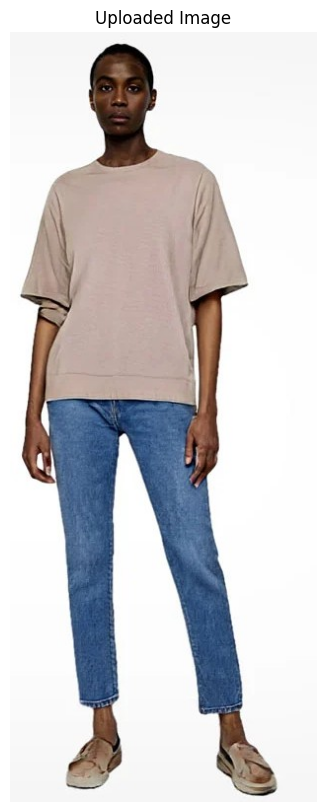

In [13]:
image_path = "ima1.jpg"

image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 10))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Uploaded Image")
plt.show()

In [14]:
model_url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task"
model_path = "pose_landmarker_lite.task"

if not os.path.exists(model_path):
    urllib.request.urlretrieve(model_url, model_path)

print("Model ready:", model_path)

Model ready: pose_landmarker_lite.task


In [15]:
base_options = python.BaseOptions(model_asset_path=model_path)

options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE
)

pose_landmarker = vision.PoseLandmarker.create_from_options(options)

print("Pose Landmarker initialized successfully")

Pose Landmarker initialized successfully


In [16]:
mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=image_rgb
)

results = pose_landmarker.detect(mp_image)

if results.pose_landmarks is None or len(results.pose_landmarks) == 0:
    print("No person detected. Please upload a clearer image.")
else:
    print("Pose detected successfully.")

Pose detected successfully.


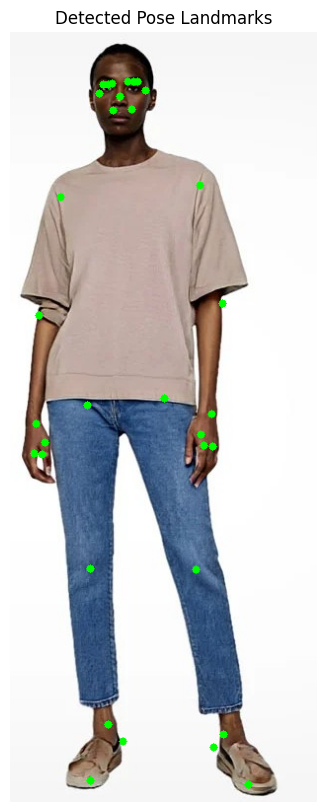

In [17]:
annotated = image_rgb.copy()
h, w, _ = annotated.shape

if results.pose_landmarks and len(results.pose_landmarks) > 0:
    landmarks = results.pose_landmarks[0]

    for lm in landmarks:
        x = int(lm.x * w)
        y = int(lm.y * h)
        cv2.circle(annotated, (x, y), 4, (0, 255, 0), -1)

plt.figure(figsize=(8, 10))
plt.imshow(annotated)
plt.axis("off")
plt.title("Detected Pose Landmarks")
plt.show()

In [18]:
h, w, _ = image.shape
landmarks = results.pose_landmarks[0]

left_shoulder = landmarks[11]
right_shoulder = landmarks[12]
left_hip = landmarks[23]
right_hip = landmarks[24]

ls = (int(left_shoulder.x * w), int(left_shoulder.y * h))
rs = (int(right_shoulder.x * w), int(right_shoulder.y * h))
lh = (int(left_hip.x * w), int(left_hip.y * h))
rh = (int(right_hip.x * w), int(right_hip.y * h))

print("Left Shoulder:", ls)
print("Right Shoulder:", rs)
print("Left Hip:", lh)
print("Right Hip:", rh)

Left Shoulder: (192, 155)
Right Shoulder: (51, 167)
Left Hip: (156, 371)
Right Hip: (78, 378)


In [19]:
shoulder_width = abs(rs[0] - ls[0])
hip_width = abs(rh[0] - lh[0])

shoulder_center_y = (ls[1] + rs[1]) // 2
hip_center_y = (lh[1] + rh[1]) // 2
torso_height = abs(hip_center_y - shoulder_center_y)

body_ratio = shoulder_width / hip_width if hip_width != 0 else 0

print("Shoulder Width:", shoulder_width)
print("Hip Width:", hip_width)
print("Torso Height:", torso_height)
print("Body Ratio:", round(body_ratio, 3))

Shoulder Width: 141
Hip Width: 78
Torso Height: 213
Body Ratio: 1.808


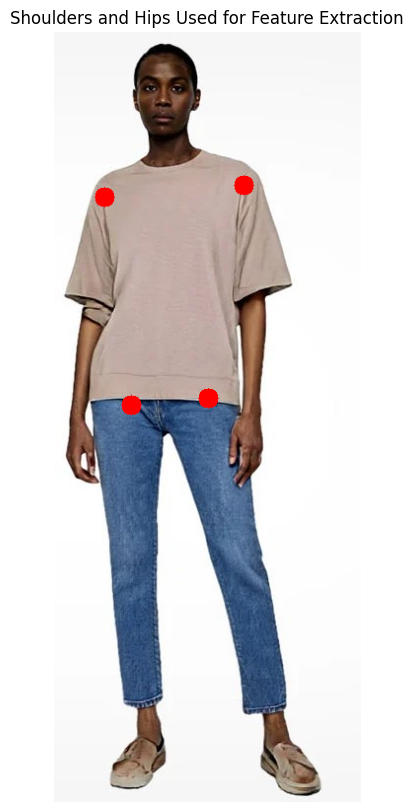

In [20]:
feature_image = image_rgb.copy()

for point in [ls, rs, lh, rh]:
    cv2.circle(feature_image, point, 10, (255, 0, 0), -1)

plt.figure(figsize=(8, 10))
plt.imshow(feature_image)
plt.axis("off")
plt.title("Shoulders and Hips Used for Feature Extraction")
plt.show()

In [31]:
user_features = {
    "shoulder_width": shoulder_width,
    "hip_width": hip_width,
    "torso_height": torso_height,
    "body_ratio": body_ratio,
    "occasion": "party",        # change if needed
    "preferred_fit": "regular", # change if needed
    "brightness": int(np.mean(image_rgb))
}

predicted_size = size_model.predict([[
    user_features["shoulder_width"],
    user_features["hip_width"],
    user_features["torso_height"],
    user_features["body_ratio"]
]])[0]

style_input = pd.DataFrame([{
    "body_ratio": user_features["body_ratio"],
    "torso_height": user_features["torso_height"],
    "occasion": user_features["occasion"],
    "preferred_fit": user_features["preferred_fit"]
}])

predicted_style = style_model.predict(style_input)[0]
predicted_colors = recommend_colors(
    user_features["brightness"],
    predicted_style,
    user_features["occasion"]
)

print("Predicted Size:", predicted_size)
print("Predicted Style:", predicted_style)
print("Predicted Colors:", predicted_colors)

Predicted Size: XL
Predicted Style: Party Wear
Predicted Colors: ['Maroon', 'Wine', 'Emerald Green', 'Black']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [32]:
user_features = {
    "shoulder_width": shoulder_width,
    "hip_width": hip_width,
    "torso_height": torso_height,
    "body_ratio": body_ratio
}

print(user_features)

{'shoulder_width': 141, 'hip_width': 78, 'torso_height': 213, 'body_ratio': 1.8076923076923077}


In [33]:
print("Shoulder Width:", shoulder_width)
print("Hip Width:", hip_width)
print("Torso Height:", torso_height)
print("Body Ratio:", round(body_ratio, 3))

Shoulder Width: 141
Hip Width: 78
Torso Height: 213
Body Ratio: 1.808


In [34]:
user_input = {
    "shoulder_width": shoulder_width,
    "hip_width": hip_width,
    "torso_height": torso_height,
    "body_ratio": body_ratio,
    "occasion": "party",         # change if needed
    "preferred_fit": "regular",  # change if needed
    "brightness": int(np.mean(image_rgb))
}

user_input

{'shoulder_width': 141,
 'hip_width': 78,
 'torso_height': 213,
 'body_ratio': 1.8076923076923077,
 'occasion': 'party',
 'preferred_fit': 'regular',
 'brightness': 200}

In [35]:
predicted_size = size_model.predict([[
    user_input["shoulder_width"],
    user_input["hip_width"],
    user_input["torso_height"],
    user_input["body_ratio"]
]])[0]

print("Predicted Size:", predicted_size)

Predicted Size: XL


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [36]:
style_input = pd.DataFrame([{
    "body_ratio": user_input["body_ratio"],
    "torso_height": user_input["torso_height"],
    "occasion": user_input["occasion"],
    "preferred_fit": user_input["preferred_fit"]
}])

style_input

,body_ratio,torso_height,occasion,preferred_fit
0,1.807692,213,party,regular


In [37]:
predicted_style = style_model.predict(style_input)[0]

print("Predicted Style:", predicted_style)

Predicted Style: Party Wear


In [38]:
def recommend_colors(brightness, style, occasion):
    if brightness >= 180:
        base = ["Navy Blue", "Maroon", "Black", "Emerald Green"]
    elif brightness >= 120:
        base = ["Teal", "Wine", "Peach", "Mustard"]
    else:
        base = ["White", "Royal Blue", "Lavender", "Olive Green"]

    if style == "Formal":
        return ["Black", "Navy Blue", "Grey", "White"]

    if style == "Party Wear":
        return ["Maroon", "Wine", "Emerald Green", "Black"]

    if style in ["Ethnic", "Traditional"]:
        return ["Royal Blue", "Magenta", "Gold", "Maroon"]

    if occasion == "college":
        return ["Blue", "White", "Peach", "Lavender"]

    return base

In [39]:
predicted_colors = recommend_colors(
    user_input["brightness"],
    predicted_style,
    user_input["occasion"]
)

print("Predicted Colors:", predicted_colors)

Predicted Colors: ['Maroon', 'Wine', 'Emerald Green', 'Black']


In [40]:
print("===== Fashion Prediction Result =====")
print("Recommended Size:", predicted_size)
print("Recommended Style:", predicted_style)
print("Recommended Colors:", ", ".join(predicted_colors))
print("Occasion:", user_input["occasion"])
print("Preferred Fit:", user_input["preferred_fit"])

===== Fashion Prediction Result =====
Recommended Size: XL
Recommended Style: Party Wear
Recommended Colors: Maroon, Wine, Emerald Green, Black
Occasion: party
Preferred Fit: regular


In [41]:
prompt = f"""
You are a smart fashion assistant.

A user's image was analyzed using pose detection.
The extracted body features are:
- Shoulder width: {user_input['shoulder_width']}
- Hip width: {user_input['hip_width']}
- Torso height: {user_input['torso_height']}
- Body ratio: {round(user_input['body_ratio'], 2)}

User preferences:
- Occasion: {user_input['occasion']}
- Preferred fit: {user_input['preferred_fit']}

System predictions:
- Recommended size: {predicted_size}
- Recommended style: {predicted_style}
- Recommended colors: {", ".join(predicted_colors)}

Now generate a helpful fashion recommendation.
Explain:
1. why this size is suitable
2. why this style is suitable
3. why these colors are suitable
4. one extra styling tip
"""

print(prompt)


You are a smart fashion assistant.

A user's image was analyzed using pose detection.
The extracted body features are:
- Shoulder width: 141
- Hip width: 78
- Torso height: 213
- Body ratio: 1.81

User preferences:
- Occasion: party
- Preferred fit: regular

System predictions:
- Recommended size: XL
- Recommended style: Party Wear
- Recommended colors: Maroon, Wine, Emerald Green, Black

Now generate a helpful fashion recommendation.
Explain:
1. why this size is suitable
2. why this style is suitable
3. why these colors are suitable
4. one extra styling tip



In [42]:
fashion_advice = f"""
Recommended Size: {predicted_size}

Recommended Style: {predicted_style}

Recommended Colors: {", ".join(predicted_colors)}

Explanation:
The uploaded image was analyzed using pose landmarks to estimate body-related features such as shoulder width, hip width, torso height, and body ratio.
Based on these measurements, size {predicted_size} appears to be suitable for balanced fit and comfort.

For the selected occasion ({user_input['occasion']}), the recommended style is {predicted_style}.
The suggested colors {", ".join(predicted_colors)} match the occasion and style well and may improve the overall appearance.

Styling Tip:
Choose accessories and footwear that complement the {predicted_style.lower()} look for a more polished appearance.
"""

print(fashion_advice)


Recommended Size: XL

Recommended Style: Party Wear

Recommended Colors: Maroon, Wine, Emerald Green, Black

Explanation:
The uploaded image was analyzed using pose landmarks to estimate body-related features such as shoulder width, hip width, torso height, and body ratio.
Based on these measurements, size XL appears to be suitable for balanced fit and comfort.

For the selected occasion (party), the recommended style is Party Wear.
The suggested colors Maroon, Wine, Emerald Green, Black match the occasion and style well and may improve the overall appearance.

Styling Tip:
Choose accessories and footwear that complement the party wear look for a more polished appearance.



In [43]:
dress_uploaded = files.upload()

Saving dress1.png to dress1.png


In [44]:
!git clone https://github.com/fashn-AI/fashn-vton-1.5.git
%cd fashn-vton-1.5
!pip install -e .

Cloning into 'fashn-vton-1.5'...
remote: Enumerating objects: 92, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 92 (delta 20), reused 13 (delta 13), pack-reused 67 (from 1)
Receiving objects: 100% (92/92), 334.44 KiB | 7.27 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/fashn-vton-1.5
Obtaining file:///content/fashn-vton-1.5
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 4.7 MB/s eta 0:00:00
  Building editable for fashn-vton (pyproject.toml) ... done
  Created wheel for fashn-vton: filename=fashn_vton-1.5.0-0.editable-py3-none-any.whl size=5771 sha256=4b191a19924ffdc1056caf0d643d8beef480c47c779c3fcdd86ec1733dfa4959
  Stored in directory: /tmp/pip-ephem-wheel-cache-73bkm_o2/wheels/83/85/d4

In [45]:
!python scripts/download_weights.py --weights-dir ./weights



model.safetensors: 100% 1.94G/1.94G [00:22<00:00, 88.1MB/s]
  Saved to: /content/fashn-vton-1.5/weights/model.safetensors

yolox_l.onnx: 100% 217M/217M [00:02<00:00, 108MB/s]
  Saved to: /content/fashn-vton-1.5/weights/dwpose/yolox_l.onnx
dw-ll_ucoco_384.onnx: 100% 134M/134M [00:01<00:00, 83.9MB/s]
  Saved to: /content/fashn-vton-1.5/weights/dwpose/dw-ll_ucoco_384.onnx

config.json: 1.65kB [00:00, 3.35MB/s]
model.safetensors: 100% 256M/256M [00:05<00:00, 49.2MB/s]
Loading weights: 100% 930/930 [00:01<00:00, 726.24it/s, Materializing param=segformer.encoder.patch_embeddings.3.proj.weight]
  Cached in HuggingFace hub cache

Download complete!

Weights directory structure:
    /content/fashn-vton-1.5/weights/
    ├── model.safetensors
    └── dwpose/
        ├── yolox_l.onnx
        └── dw-ll_ucoco_384.onnx

Usage:
    from fashn_vton import TryOnPipeline
    pipeline = TryOnPipeline(weights_dir="/content/fashn-vton-1.5/weights")



In [46]:
from google.colab import files

print("Upload the PERSON image")
person_upload = files.upload()

print("Upload the DRESS image")
garment_upload = files.upload()

Upload the PERSON image


Saving ima1.jpg to ima1.jpg
Upload the DRESS image


Saving dress1.png to dress1.png


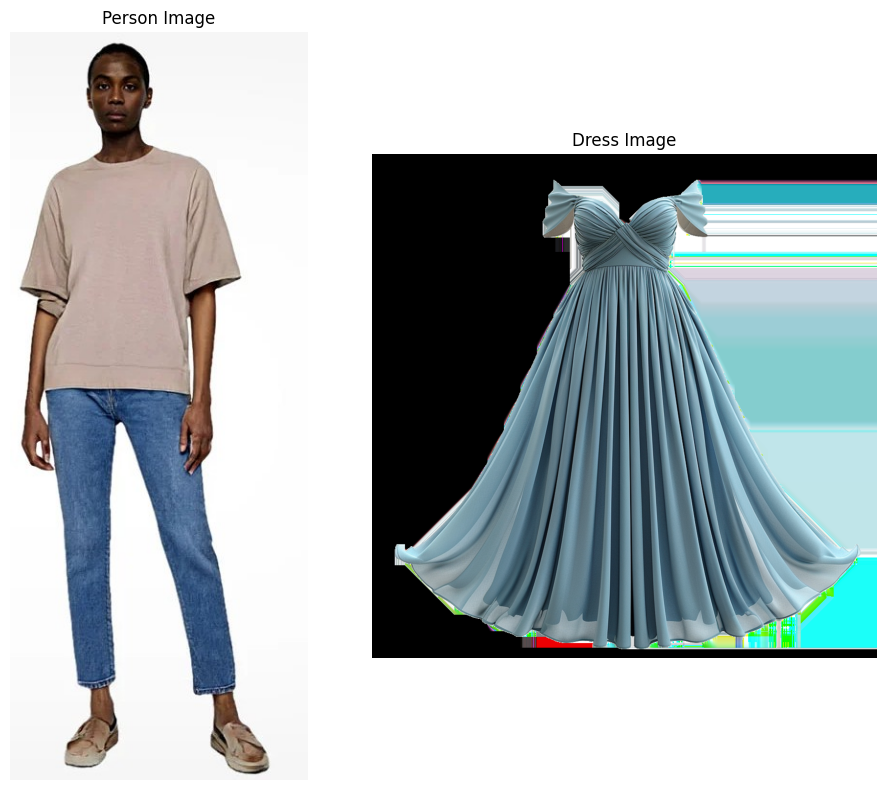

In [47]:
from PIL import Image
import matplotlib.pyplot as plt

person_path = "ima1.jpg"
garment_path = "dress1.png"

person = Image.open(person_path).convert("RGB")
garment = Image.open(garment_path).convert("RGB")

fig, axes = plt.subplots(1, 2, figsize=(10, 8))
axes[0].imshow(person)
axes[0].axis("off")
axes[0].set_title("Person Image")

axes[1].imshow(garment)
axes[1].axis("off")
axes[1].set_title("Dress Image")

plt.tight_layout()
plt.show()

In [48]:
!git clone https://github.com/fashn-AI/fashn-vton-1.5.git

Cloning into 'fashn-vton-1.5'...
remote: Enumerating objects: 92, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 92 (delta 20), reused 13 (delta 13), pack-reused 67 (from 1)
Receiving objects: 100% (92/92), 334.44 KiB | 6.19 MiB/s, done.
Resolving deltas: 100% (29/29), done.


In [49]:
%cd fashn-vton-1.5

/content/fashn-vton-1.5/fashn-vton-1.5


In [50]:
!pip install -e .

Obtaining file:///content/fashn-vton-1.5/fashn-vton-1.5
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for fashn-vton (pyproject.toml) ... done
  Created wheel for fashn-vton: filename=fashn_vton-1.5.0-0.editable-py3-none-any.whl size=5773 sha256=394ee949f806751395f5481d99519c5e8f8794ddeae7098cceeb7d5aa03c3eaa
  Stored in directory: /tmp/pip-ephem-wheel-cache-kqlfchy3/wheels/3d/7a/c6/5991f257d5ea32a394d123f21dd1ed10a7273e89dae9b5b40a
Successfully built fashn-vton
  Attempting uninstall: fashn-vton
    Found existing installation: fashn-vton 1.5.0
    Uninstalling fashn-vton-1.5.0:
      Successfully uninstalled fashn-vton-1.5.0


In [51]:
!python scripts/download_weights.py --weights-dir ./weights



model.safetensors: 100% 1.94G/1.94G [00:23<00:00, 84.4MB/s]
  Saved to: /content/fashn-vton-1.5/fashn-vton-1.5/weights/model.safetensors

yolox_l.onnx: 100% 217M/217M [00:02<00:00, 98.4MB/s]
  Saved to: /content/fashn-vton-1.5/fashn-vton-1.5/weights/dwpose/yolox_l.onnx
dw-ll_ucoco_384.onnx: 100% 134M/134M [00:01<00:00, 83.8MB/s]
  Saved to: /content/fashn-vton-1.5/fashn-vton-1.5/weights/dwpose/dw-ll_ucoco_384.onnx

Loading weights: 100% 930/930 [00:01<00:00, 725.53it/s, Materializing param=segformer.encoder.patch_embeddings.3.proj.weight]
  Cached in HuggingFace hub cache

Download complete!

Weights directory structure:
    /content/fashn-vton-1.5/fashn-vton-1.5/weights/
    ├── model.safetensors
    └── dwpose/
        ├── yolox_l.onnx
        └── dw-ll_ucoco_384.onnx

Usage:
    from fashn_vton import TryOnPipeline
    pipeline = TryOnPipeline(weights_dir="/content/fashn-vton-1.5/fashn-vton-1.5/weights")



In [52]:
import sys
sys.path.append("/content/fashn-vton-1.5")

In [53]:
!ls

examples  LICENSE  pyproject.toml  README.md  scripts  src  tests  weights


In [54]:
import sys
sys.path.append("/content/fashn-vton-1.5/src")

In [55]:
from fashn_vton import TryOnPipeline

pipeline = TryOnPipeline(weights_dir="./weights")

print("Pipeline loaded successfully")

TryOnPipeline - INFO - Using device: cuda
TryOnPipeline - INFO - Using dtype: torch.bfloat16
TryOnPipeline - INFO - Loading TryOnModel from /content/fashn-vton-1.5/fashn-vton-1.5/weights/model.safetensors
TryOnPipeline - INFO - TryOnModel loaded
TryOnPipeline - INFO - Loading DWPose from /content/fashn-vton-1.5/fashn-vton-1.5/weights/dwpose
TryOnPipeline - INFO - DWPose loaded
TryOnPipeline - INFO - Loading FashnHumanParser
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

TryOnPipeline - INFO - FashnHumanParser loaded


Pipeline loaded successfully


In [56]:
from google.colab import files

print("Upload PERSON image")
person_upload = files.upload()

print("Upload DRESS image")
dress_upload = files.upload()

Upload PERSON image


Saving ima1.jpg to ima1.jpg
Upload DRESS image


Saving dress1.png to dress1.png


In [58]:
from PIL import Image

person = Image.open("ima1.jpg").convert("RGB")
dress = Image.open("dress1.png").convert("RGB")

result = pipeline(
    person_image=person,
    garment_image=dress,
    category="one-pieces"
)

result

TryOnPipeline - INFO - Running inference with 30 timesteps...


Sampling:   0%|          | 0/30 [00:00<?, ?it/s]

TryOnPipeline - INFO - Generated 1 images


PipelineOutput(images=[<PIL.Image.Image image mode=RGB size=344x864 at 0x7829A43BC620>])

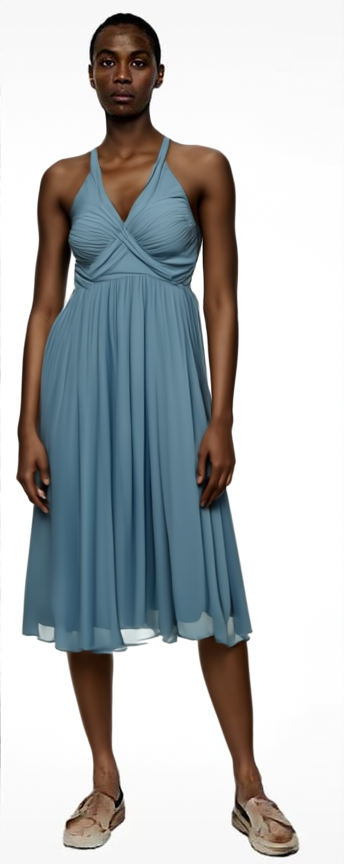

In [59]:
result_image = result.images[0]
result_image